<a href="https://colab.research.google.com/github/omaralonsoinfo/MineriaDeDatos/blob/main/Porcentaje%20de%20colores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving munsell-array-fixed-choice.csv to munsell-array-fixed-choice.csv


In [2]:
import pandas as pd
df = pd.read_csv('munsell-array-fixed-choice.csv')

In [3]:
df

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)
...,...,...,...,...,...,...,...,...,...,...
75,H19,19,1,5RP2/8,#591340,purple,purple,purple,morado (purple),itsidyeisi (purple)
76,A20,20,8,10RP9/2,#efdfe0,pink,white,white,blanco (white),jaibas (white)
77,C20,20,6,10RP7/8,#ea95a0,pink,pink,red,rosada (pink),jainas (red)
78,E20,20,4,10RP5/14,#d73f6a,pink,pink,red,rosada (pink),jainas (red)


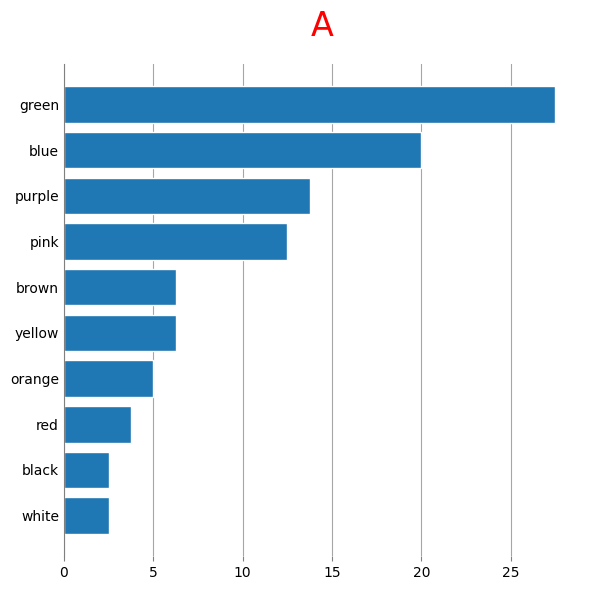

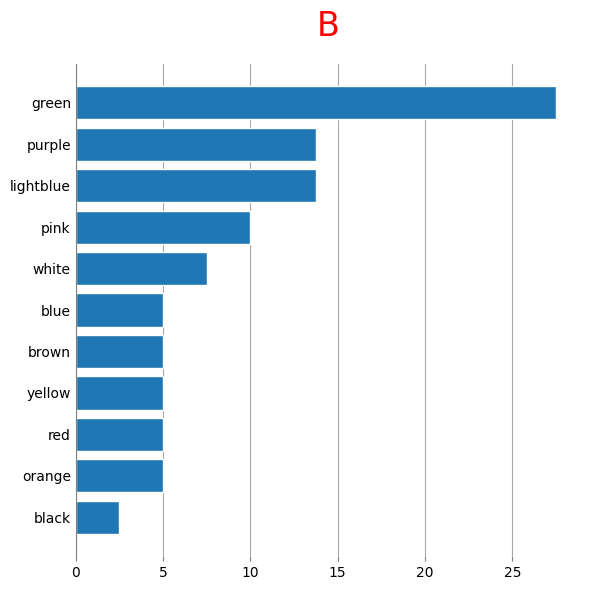

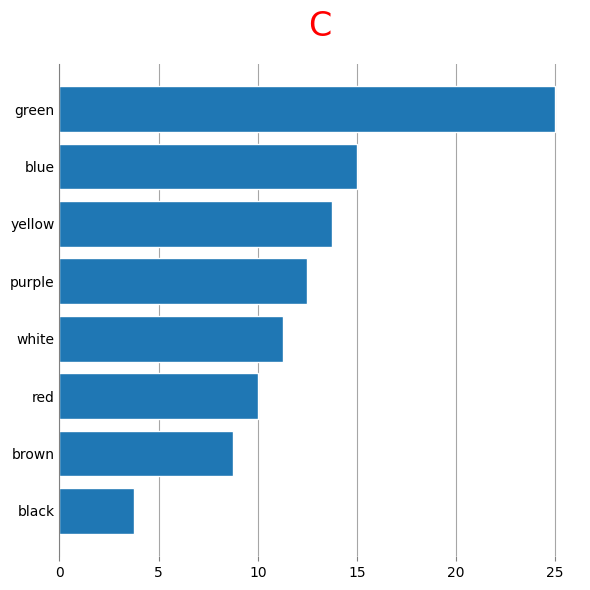

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_color_percentages(df, column_name, title):
    # 2. Calcular los porcentajes
    # value_counts() cuenta las ocurrencias. normalize=True lo hace proporción (0 a 1)
    percentages = df[column_name].value_counts(normalize=True) * 100

    # Ordenar de menor a mayor para que al graficar en horizontal, el mayor quede arriba
    percentages = percentages.sort_values(ascending=True)

    # 3. Crear la gráfica
    fig, ax = plt.subplots(figsize=(6, 6))

    # Dibujar barras horizontales
    ax.barh(percentages.index, percentages.values, color='#1f77b4', edgecolor='white')

    # 4. Formatear la gráfica para que se vea como en tus imágenes
    ax.set_title(title, fontsize=24, color='red', pad=20)

    # Agregar las líneas de cuadrícula verticales
    ax.xaxis.grid(True, linestyle='-', color='grey', alpha=0.7)
    # Poner la cuadrícula por detrás de las barras
    ax.set_axisbelow(True)

    # Quitar los bordes de la caja (arriba, derecha, izquierda)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('grey')
    ax.spines['bottom'].set_visible(False)

    # Quitar las marcas del eje y (los guiones junto a los nombres)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', color='grey')

    plt.tight_layout()
    plt.show()



# Gráfica A: Colores en Inglés
plot_color_percentages(df, 'english_color', 'A')

# Gráfica B: Colores en Español
plot_color_percentages(df, 'spanish_color', 'B')

# Gráfica C: Colores Tsimane
plot_color_percentages(df, 'tsimane_color', 'C')

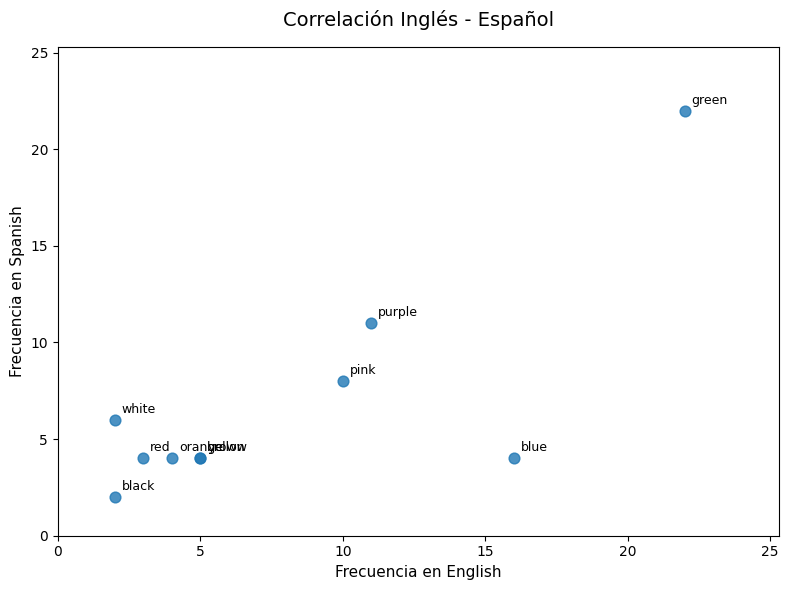

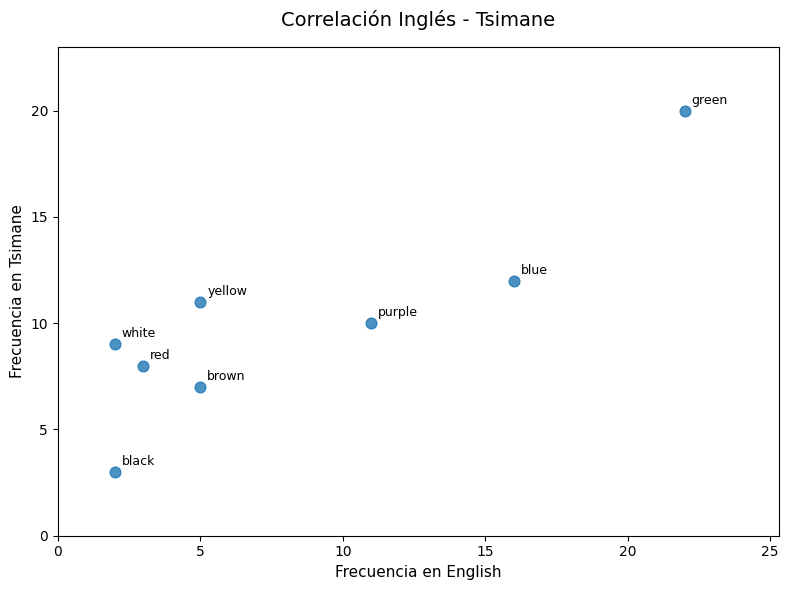

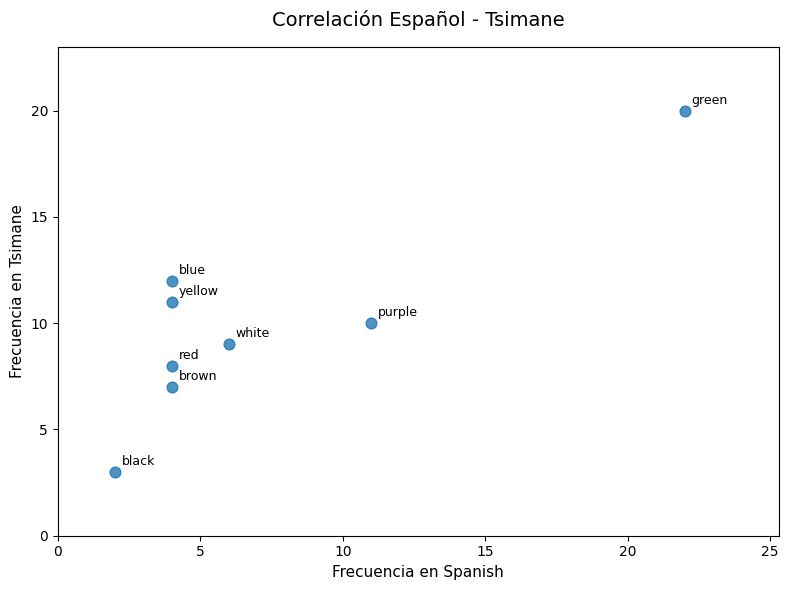

In [12]:
# Creamos DataFrames de frecuencias para cada idioma
english_df = df['english_color'].value_counts().reset_index()
english_df.columns = ['color', 'count_en']

spanish_df = df['spanish_color'].value_counts().reset_index()
spanish_df.columns = ['color', 'count_es']

tsimane_df = df['tsimane_color'].value_counts().reset_index()
tsimane_df.columns = ['color', 'count_ts']

# 2. Definición de los pares de correlación
# Usamos 'inner' join para asegurar que solo graficamos colores que existen en ambos idiomas del par
pares = [
    {'name': 'Inglés - Español', 'df1': english_df, 'df2': spanish_df, 'col1': 'count_en', 'col2': 'count_es', 'lab1': 'English', 'lab2': 'Spanish'},
    {'name': 'Inglés - Tsimane', 'df1': english_df, 'df2': tsimane_df, 'col1': 'count_en', 'col2': 'count_ts', 'lab1': 'English', 'lab2': 'Tsimane'},
    {'name': 'Español - Tsimane', 'df1': spanish_df, 'df2': tsimane_df, 'col1': 'count_es', 'col2': 'count_ts', 'lab1': 'Spanish', 'lab2': 'Tsimane'}
]


for par in pares:
    # Unir los datos por la columna 'color'
    merged = pd.merge(par['df1'], par['df2'], on='color', how='inner')

    # Crear la figura
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

    # Graficar puntos
    ax.scatter(merged[par['col1']], merged[par['col2']], s=60, color='tab:blue', alpha=0.8)


    for i, row in merged.iterrows():
        ax.annotate(
            row['color'],
            (row[par['col1']], row[par['col2']]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9
        )


    ax.grid(False)
    ax.set_facecolor('white')
    ax.set_title(f"Correlación {par['name']}", fontsize=14, pad=15)
    ax.set_xlabel(f"Frecuencia en {par['lab1']}", fontsize=11)
    ax.set_ylabel(f"Frecuencia en {par['lab2']}", fontsize=11)

    # Ajuste de límites para dejar espacio a las etiquetas
    ax.set_xlim(left=0, right=merged[par['col1']].max() * 1.15)
    ax.set_ylim(bottom=0, top=merged[par['col2']].max() * 1.15)

    plt.tight_layout()
    plt.show()
